# Разведочный анализ данных
---

### 0. Импорт библиотек, загрузка данных, настройка ноутбука

In [72]:
import numpy as np
import pandas as pd
from scipy.stats import entropy
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
pd.set_option('display.max_columns', None)

#### Источник датасета:
https://archive.ics.uci.edu/dataset/174/parkinsons

In [60]:
df = pd.read_csv('parkinsons.csv')

### 1. Описание данных

In [61]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


#### Таблица 1. Описание переменных в наборе данных по болезни Паркинсона:

| Переменные | Описание |
|-----------|----------|
| `name` | Имя пациента в ASCII и номер записи |
| `MDVP:Fo(Hz)` | Средняя фундаментальная частота голоса |
| `MDVP:Fhi(Hz)` | Максимальная фундаментальная частота голоса |
| `MDVP:Flo(Hz)` | Минимальная фундаментальная частота голоса |
| `MDVP:Jitter(%)`, `MDVP:Jitter(Abs)`, `MDVP:RAP`, `MDVP:PPQ`, `Jitter:DDP` | Несколько показателей колебаний фундаментальной частоты |
| `MDVP:Shimmer`, `MDVP:Shimmer(dB)`, `Shimmer:APQ3`, `Shimmer:APQ5`, `MDVP:APQ`, `Shimmer:DDA` | Несколько показателей колебаний амплитуды |
| `NHR`, `HNR` | Два показателя соотношения шума и тональных компонентов в голосе |
| `status` | Состояние здоровья испытуемого: 1 — болезнь Паркинсона, 0 — здоров |
| `RPDE`, `D2` | Два показателя нелинейной динамической сложности |
| `DFA` | Экспонента фрактального масштабирования сигнала |
| `spread1`, `spread2`, `PPE` | Три нелинейных показателя вариации фундаментальной частоты |

### Подробное описание акустических параметров голоса

**Группа A. Частота основного тона (Fo)**

MDVP:Fo(Hz) — средняя частота основного тона (средний pitch).

MDVP:Fhi(Hz) — максимальная частота (верхняя граница pitch).

MDVP:Flo(Hz) — минимальная частота (нижняя граница pitch).

Fo связан с частотой вибрации голосовых складок и их натяжением. При Паркинсоне часто наблюдается монотонность (сужение диапазона частот), трудности с контролем вариаций pitch.

**Группа B. Jitter — микро-нестабильность частоты (периодичности)**

MDVP:Jitter(%), MDVP:Jitter(Abs), MDVP:RAP, MDVP:PPQ, Jitter:DDP

Jitter отражает нерегулярность периода колебаний голосовых складок (cycle-to-cycle). Повышение jitter типично при дисфонии, неполном контроле смыкания/натяжения складок и нейромоторной нестабильности. Для Паркинсона это ожидаемо из-за нарушенной регуляции моторики (ригидность/тремор/брадикинезия).

**Группа C. Shimmer — микро-нестабильность амплитуды (громкости)**

MDVP:Shimmer, MDVP:Shimmer(dB), Shimmer:APQ3, Shimmer:APQ5, MDVP:APQ, Shimmer:DDA

Shimmer показывает, насколько нестабильна амплитуда звука от цикла к циклу. Рост shimmer часто связан с:

гипотонией/неустойчивым смыканием голосовых складок, «воздушностью»/утечкой воздуха, слабостью фонации. При Паркинсоне это может отражать hypophonia и ухудшение контроля фонации.

**Группа D. Шумовые компоненты голоса**

NHR — отношение шума к гармоникам (чем выше, тем «шумнее» голос).

HNR — отношение гармоник к шуму (чем ниже, тем хуже качество тонального компонента).

Увеличение шумового компонента характерно при:

неполном смыкании голосовых складок, дисфонии, дыхательной примеси, что может усиливаться при нейромоторных расстройствах.

**Группа E. Нелинейная динамика/сложность сигнала (биосигнальная «нерегулярность»)**

RPDE, D2, DFA, spread1, spread2, PPE

Это признаки, описывающие сложность и хаотичность голосового сигнала. Они полезны, когда обычных jitter/shimmer недостаточно: при нейродегенерации меняется стабильность фонации и структура вариабельности голоса → сигнал становится менее «упорядоченным».

Акустические признаки отражают:

- частотные характеристики голоса
- стабильность периодичности (jitter)
- стабильность амплитуды (shimmer)
- уровень шумовых компонентов (NHR/HNR)
- нелинейную динамику и сложность голосового сигнала

Эти параметры клинически релевантны для болезни Паркинсона, так как отражают типичные изменения фонации при гипокинетической дизартрии и нарушении моторного контроля голосовых складок.

In [62]:
df.shape

(195, 24)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

#### Итоги по описанию данных

**Oxford Parkinson’s Disease Detection Dataset** содержит *195* строк и *24* столбца, где каждое наблюдение является отдельной записью голоса, которая связанна с конкретным человеком. Номинальные переменные в данных являются `name` (категориальный идентификатор записи) и `status` (номинальная бинарная метка класса, где 0 — здоровый человек, а 1 — пациент с болезнью Паркинсона). Оставшиеся 22 колонки содержащие биомедицинские измерения голоса, такие как частоты (`MDVP:Fo(Hz)`, `MDVP:Fhi(Hz)`, `MDVP:Flo(Hz)`), показатели jitter/shimmer, отношения шум–тон (`NHR`, `HNR`) и нелинейные характеристики (`RPDE`, `DFA`, `D2`, `PPE`, `spread1`, `spread2`) являются количественными признаками.


Для болезни Паркинсона типична гипокинетическая дизартрия:

- снижение громкости (hypophonia),

- монотонность (узкий диапазон Fo),

- «дыхательный/шумный» компонент,

- нестабильность колебаний голосовых складок (нарушение периодичности),

- тремор/ригидность и ухудшение тонкой моторики → микронестабильность частоты и амплитуды. Именно это и отражают показатели jitter/shimmer/шум/нелинейная динамика.

### 2. Проверка пропусков

In [64]:
df.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


#### Итоги по проверки пропусков

Пропусков в данных **нет**.

### 3. Проверка типов переменных

Проверим типы отдельно для идентификатора, целевой переменной и признаков.

In [65]:
# 1) Тип идентификатора
df['name'].dtype

dtype('O')

In [66]:
# 2) Тип целевой переменной
df['status'].dtype

dtype('int64')

In [67]:
# 3) Какие значения и в каком количестве встречаются в `status`
df['status'].value_counts().sort_index()

,count
status,
0,48
1,147


In [68]:
# 4) Проверяем, что признаки (кроме `name` и `status`) числовые
feature_cols = [c for c in df.columns if c not in ['name', 'status']]
non_numeric = df[feature_cols].select_dtypes(exclude=['int64', 'float64']).columns.tolist()
non_numeric

[]

#### Итоги по проверке типов переменных
* `name` хранится как строковый идентификатор.
* `status` хранится как число и принимает значения **0** и **1**.
* остальные столбцы являются числовыми.

### 4. Описательная статистика

Посчитаем базовые статистики для числовых признаков и отдельно посмотрим распределение `status`.

In [15]:
# Доли классов (в процентах)
df['status'].value_counts(normalize=True).sort_index() * 100

,proportion
status,
0,24.615385
1,75.384615


In [16]:
# Описательные статистики для числовых признаков
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [17]:
# Сколько записей в данных
df['name'].nunique()

195

In [23]:
# Сколько "людей" в данных (в `name` зашит идентификатор субъекта)
df['patient'] = df['name'].astype(str).str.rsplit('_', n=1).str[0]
df['patient'].nunique()

32

In [24]:
# Сколько пациентов относится к каждому классу
df.groupby('status')['patient'].nunique()

,patient
status,
0,8
1,24


#### Итоги по описательной статистике

* В данных есть дисбаланс классов: больше записей с `status = 1`, чем с `status = 0`.
* Для числовых признаков посчитаны основные показатели: среднее, стандартное отклонение, минимумы/максимумы и квартили.
* В таблице есть несколько записей на одного человека (субъекта), так как `name` содержит повторы по `subject_id`.

### 5.1. Проверка очевидных ошибок в значениях

Проверим простые правила здравого смысла: частоты и jitter/shimmer не должны быть отрицательными, а некоторые показатели лежат в диапазоне [0, 1].

In [25]:
# Простые правила для «очевидных ошибок»
rules = {
    "MDVP:Fo(Hz)": (0.0, None),
    "MDVP:Fhi(Hz)": (0.0, None),
    "MDVP:Flo(Hz)": (0.0, None),

    "MDVP:Jitter(%)": (0.0, None),
    "MDVP:Jitter(Abs)": (0.0, None),
    "MDVP:RAP": (0.0, None),
    "MDVP:PPQ": (0.0, None),
    "Jitter:DDP": (0.0, None),

    "MDVP:Shimmer": (0.0, None),
    "MDVP:Shimmer(dB)": (0.0, None),
    "Shimmer:APQ3": (0.0, None),
    "Shimmer:APQ5": (0.0, None),
    "MDVP:APQ": (0.0, None),
    "Shimmer:DDA": (0.0, None),

    "NHR": (0.0, None),
    "HNR": (0.0, None),

    "RPDE": (0.0, 1.0),
    "DFA": (0.0, 1.0),

    "spread2": (0.0, None),
    "D2": (0.0, None),
    "PPE": (0.0, None),
}

violations = {}

for col, (lo, hi) in rules.items():
    s = df[col]
    bad = pd.Series(False, index=s.index)
    if lo is not None:
        bad |= s < lo
    if hi is not None:
        bad |= s > hi
    cnt = int(bad.sum())
    if cnt > 0:
        violations[col] = cnt

violations

{}

#### Итоги по проверке очевидных ошибок в значениях

По выбранным простым правилам **ошибок не найдено** (нарушений диапазонов нет).

### 5.2. Оценка выбросов

Посмотрим, есть ли выбросы в данных и как они распределены в соответствии с целевой переменной

In [29]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_lower = (series < lower_bound).sum()
    outliers_upper = (series > upper_bound).sum()

    return outliers_lower, outliers_upper

In [32]:
outliers_df_per_class = pd.DataFrame({'column': [], 'outliers_lower0': [], 'outliers_upper0': [],
                             'outliers_lower1': [], 'outliers_upper1': []})

for f in feature_cols:
  out_l0, out_up0 = count_outliers_iqr(df[df['status'] == 0][f])
  out_l1, out_up1 = count_outliers_iqr(df[df['status'] == 1][f])
  outliers_df_per_class.loc[len(outliers_df_per_class)] = [f, out_l0, out_up0, out_l1, out_up1]

outliers_df_per_class

,column,outliers_lower0,outliers_upper0,outliers_lower1,outliers_upper1
0,MDVP:Fo(Hz),0,0,0,0
1,MDVP:Fhi(Hz),0,2,0,9
2,MDVP:Flo(Hz),0,0,0,0
3,MDVP:Jitter(%),0,3,0,13
4,MDVP:Jitter(Abs),0,1,0,9
5,MDVP:RAP,0,8,0,14
6,MDVP:PPQ,0,5,0,13
7,Jitter:DDP,0,8,0,14
8,MDVP:Shimmer,0,1,0,6
9,MDVP:Shimmer(dB),0,1,0,8


По методу межквартильного размаха были обнаружены выбросы. Чаще всего выбросы наблюдаются в признаках NHR, Jitter:DDP, MDVP:RAP, MDVP:Jitter(%), MDVP:PPQ, MDVP:Fhi(Hz), MDVP:Jitter(Abs) (тональная частота и основная частота). Больше всего выбросов наблюдается в признаках записей, относящихся к классу наличия болезни.

### 6. Корреляции

Построим тепловую карту корреляций.

In [44]:
# Матрица корреляций (Пирсон)
corr = df[feature_cols + ['status']].corr(numeric_only=True)
corr.iloc[:5, :5]

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs)
MDVP:Fo(Hz),1.000000,0.400985,0.596546,-0.118003,-0.382027
MDVP:Fhi(Hz),0.400985,1.000000,0.084951,0.102086,-0.029198
MDVP:Flo(Hz),0.596546,0.084951,1.000000,-0.139919,-0.277815
MDVP:Jitter(%),-0.118003,0.102086,-0.139919,1.000000,0.935714
MDVP:Jitter(Abs),-0.382027,-0.029198,-0.277815,0.935714,1.000000


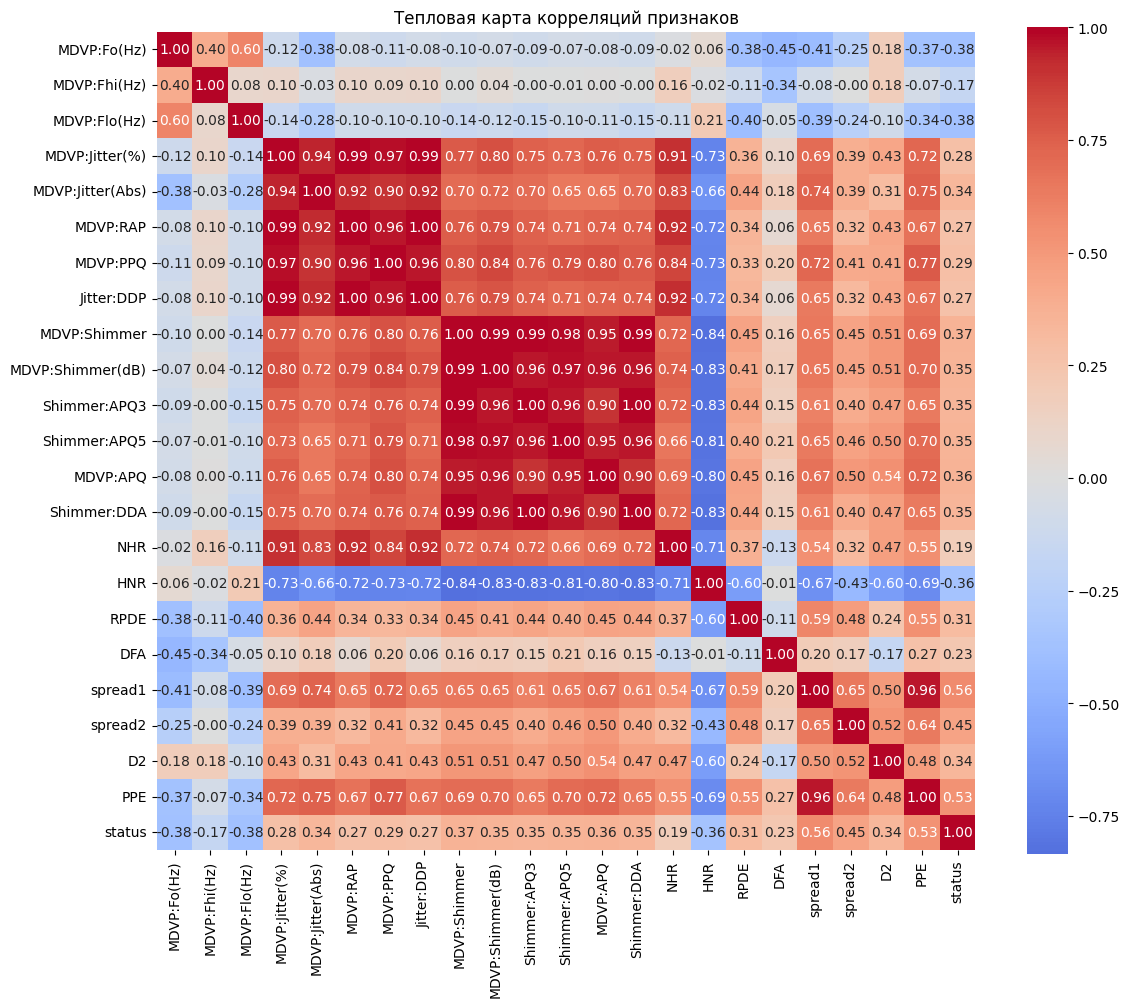

In [45]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, annot=True, fmt=".2f")
plt.title("Тепловая карта корреляций признаков")
plt.tight_layout()
plt.show()


Наиболее сильно с диагнозом коррелируют показатели, связанные с показателями вариации фундаментальной частоты (spread1, spread2, PPE), фундаментальной (MDVP)частотой и колебанием амплитуды (Shimmer)

Из матрицы корреляций видно, что в данных много скоррелированных признаков. Особенно высокие показатели корреляции видны для разных показателей одной характеристики (например, основной частоты MDVP и вариации амплитуды Shimmer), что естественно из-за природы признаков.

### 7. Графики

Построим несколько базовых графиков, чтобы визуально посмотреть на данные.

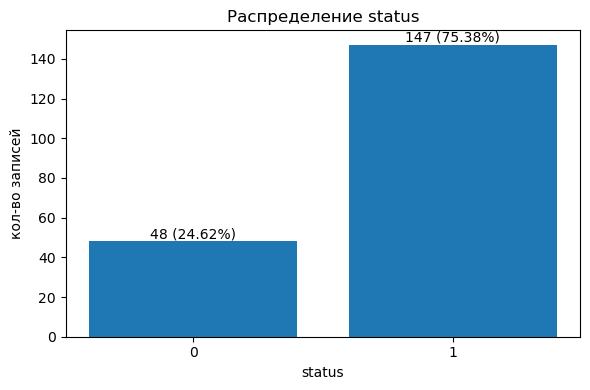

In [ ]:
# 1) Распределение целевой переменной (status)
counts = df['status'].value_counts().sort_index()
pct = (counts / len(df) * 100).round(2)

plt.figure(figsize=(6, 4))
plt.bar([str(i) for i in counts.index], counts.values)
plt.title("Распределение status")
plt.xlabel("status")
plt.ylabel("кол-во записей")

for i, k in enumerate(counts.index):
    plt.text(i, counts.loc[k], f"{int(counts.loc[k])} ({pct.loc[k]}%)", ha="center", va="bottom")

plt.tight_layout()
plt.show()


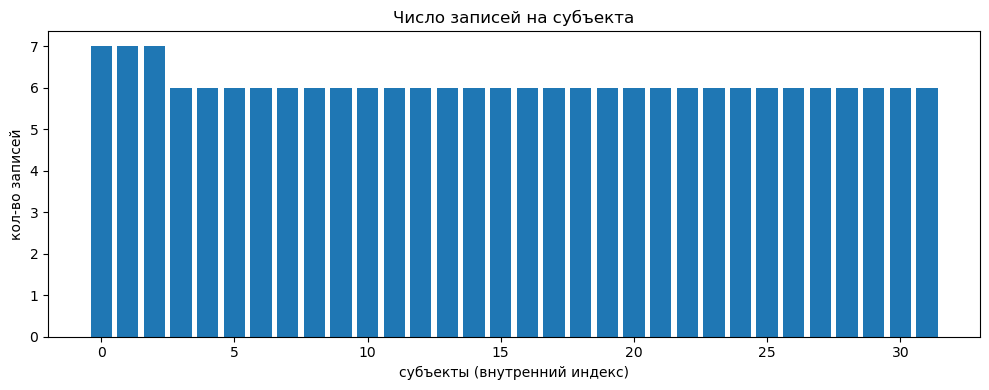

count    32.000000
mean      6.093750
std       0.296145
min       6.000000
25%       6.000000
50%       6.000000
75%       6.000000
max       7.000000
Name: count, dtype: float64

In [ ]:
# 2) Сколько записей приходится на одного субъекта
subj_counts = subject_id.value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(range(len(subj_counts)), subj_counts.values)
plt.title("Число записей на субъекта")
plt.xlabel("субъекты (внутренний индекс)")
plt.ylabel("кол-во записей")
plt.tight_layout()
plt.show()

subj_counts.describe()


#### 7.1 Распределения признаков по классам

Чтобы не строить 22 графика в одной ячейке, разобьём признаки на группы (частоты, jitter, shimmer и остальные).

In [ ]:
# Группы признаков (просто для удобства)
freq_cols = ["MDVP:Fo(Hz)", "MDVP:Fhi(Hz)", "MDVP:Flo(Hz)"]

jitter_cols = ["MDVP:Jitter(%)", "MDVP:Jitter(Abs)", "MDVP:RAP", "MDVP:PPQ", "Jitter:DDP"]

shimmer_cols = ["MDVP:Shimmer", "MDVP:Shimmer(dB)", "Shimmer:APQ3", "Shimmer:APQ5", "MDVP:APQ", "Shimmer:DDA"]

other_cols = [c for c in feature_cols if c not in freq_cols + jitter_cols + shimmer_cols]

In [ ]:
len(freq_cols), len(jitter_cols), len(shimmer_cols), len(other_cols)

(3, 5, 6, 8)

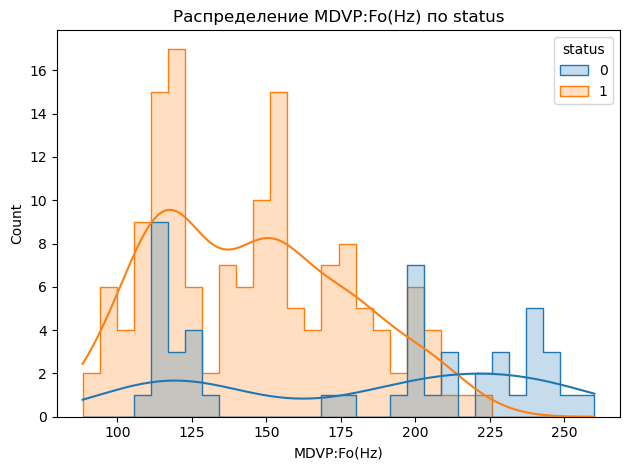

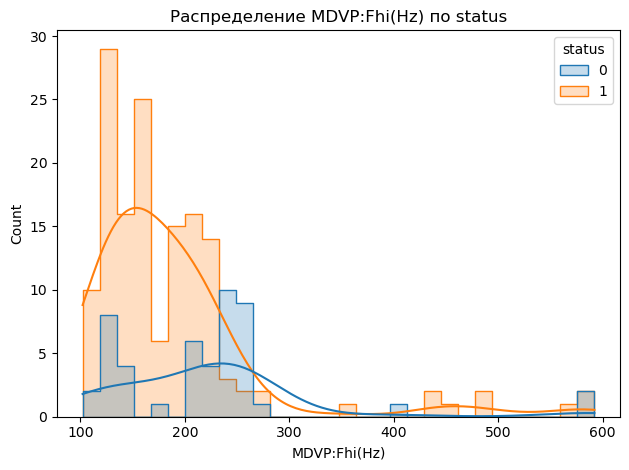

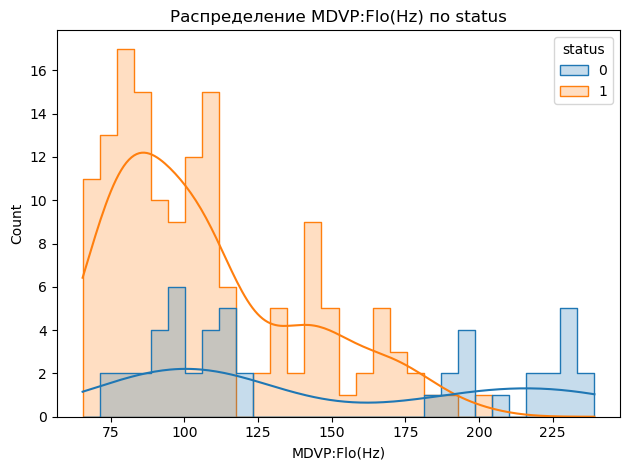

In [ ]:
# 3) Частотные признаки
for col in freq_cols:
    sns.histplot(data=df, x=col, hue="status", bins=30, kde=True, element="step", common_norm=False)
    plt.title(f"Распределение {col} по status")
    plt.tight_layout()
    plt.show()


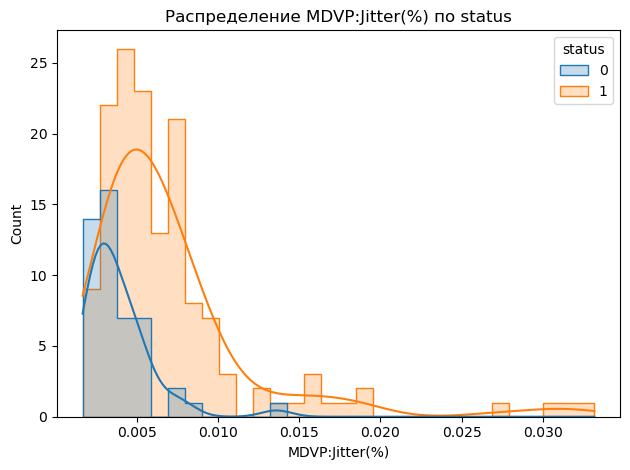

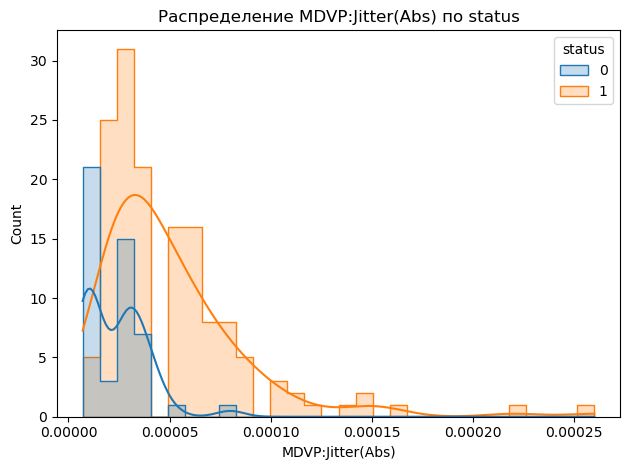

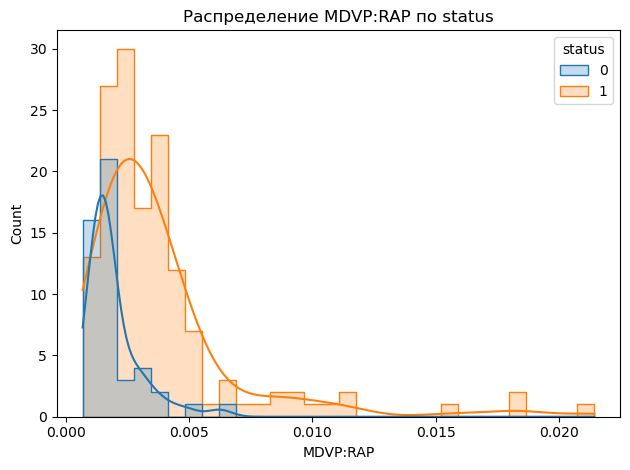

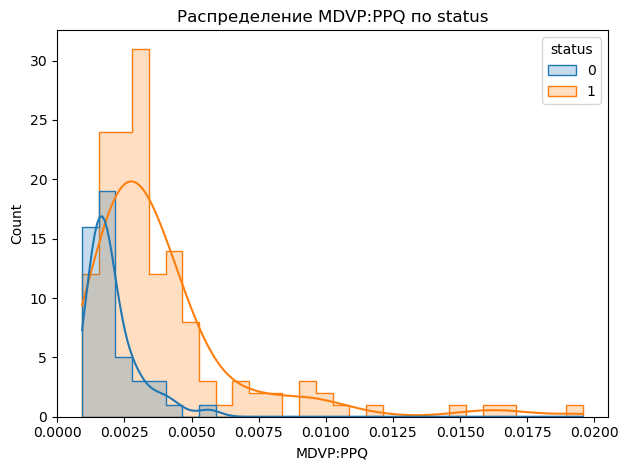

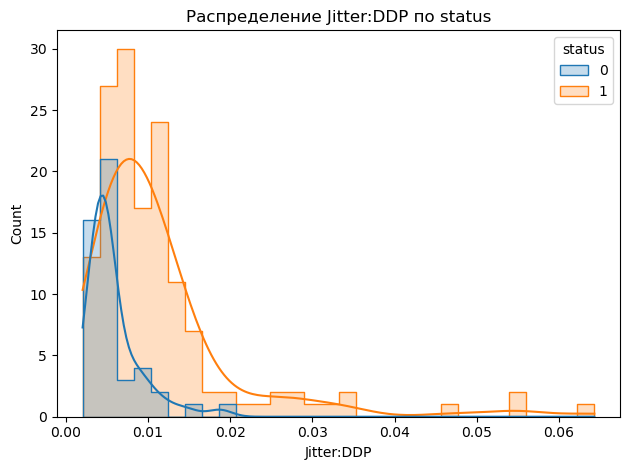

In [ ]:
# 4) Jitter-признаки
for col in jitter_cols:
    sns.histplot(data=df, x=col, hue="status", bins=30, kde=True, element="step", common_norm=False)
    plt.title(f"Распределение {col} по status")
    plt.tight_layout()
    plt.show()


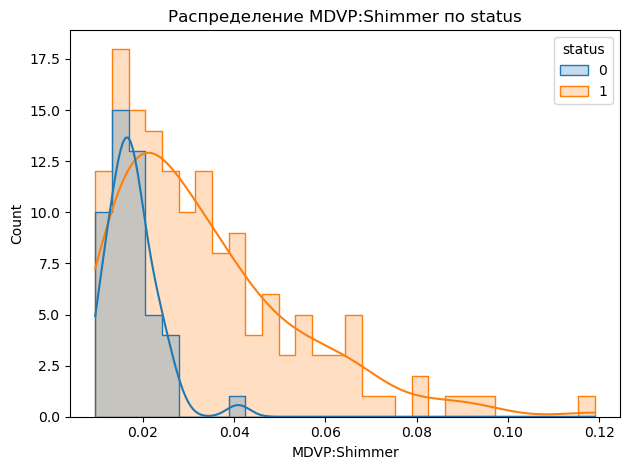

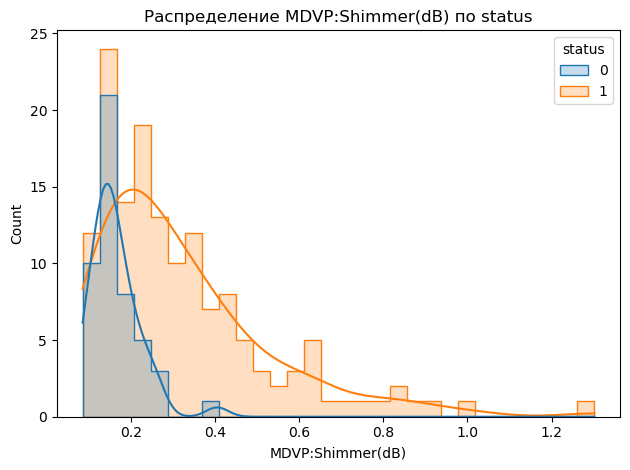

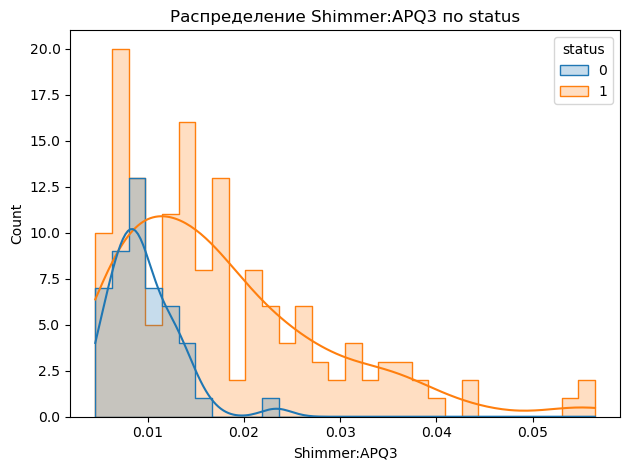

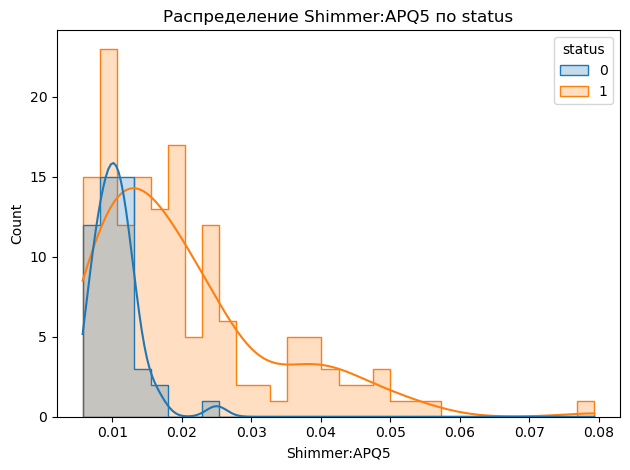

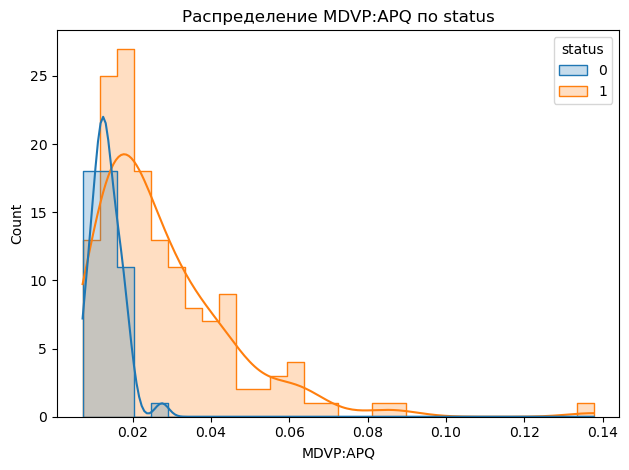

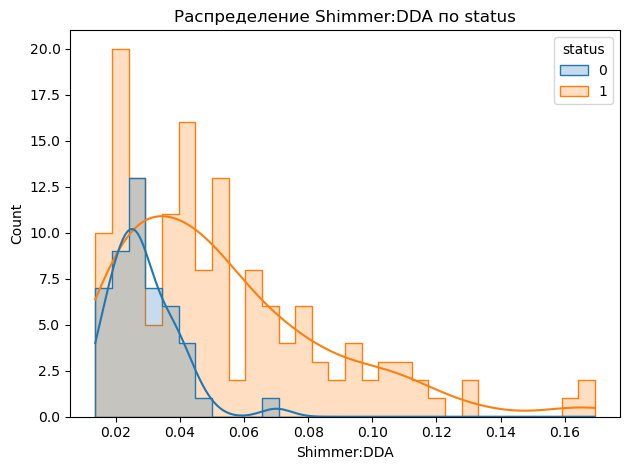

In [ ]:
# 5) Shimmer-признаки
for col in shimmer_cols:
    sns.histplot(data=df, x=col, hue="status", bins=30, kde=True, element="step", common_norm=False)
    plt.title(f"Распределение {col} по status")
    plt.tight_layout()
    plt.show()


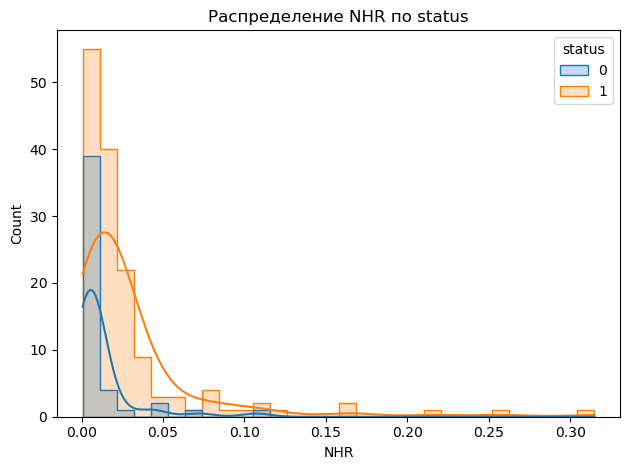

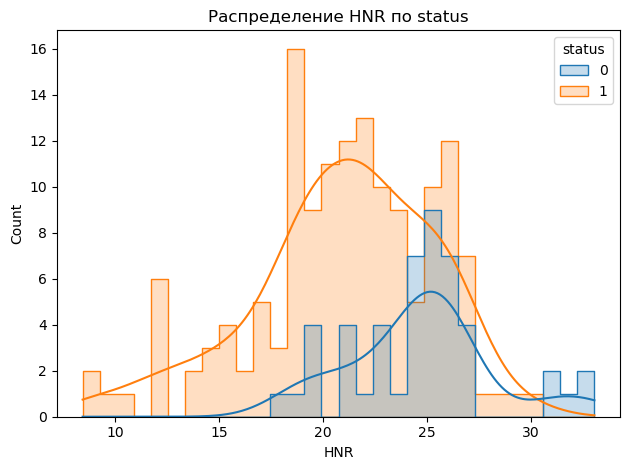

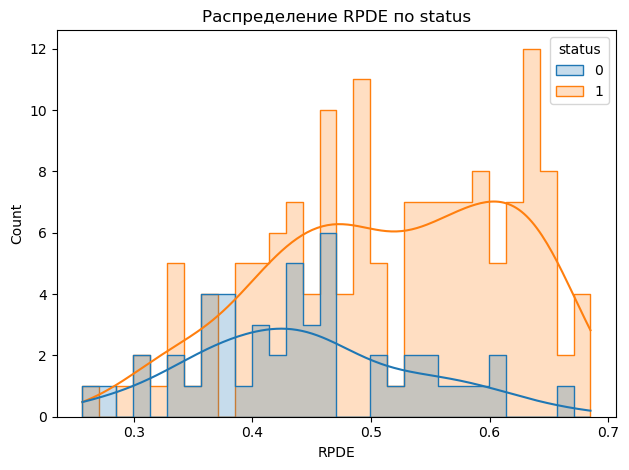

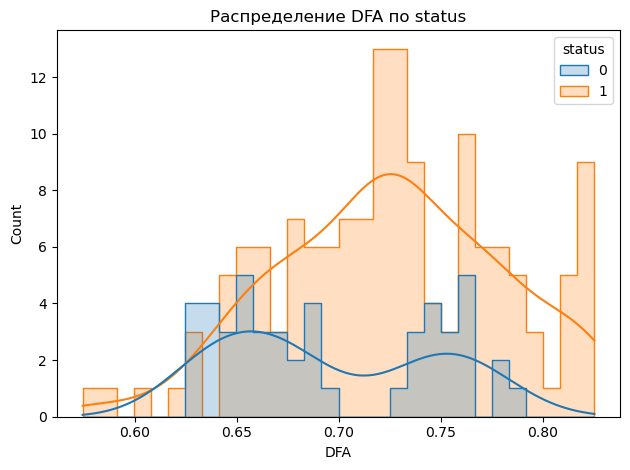

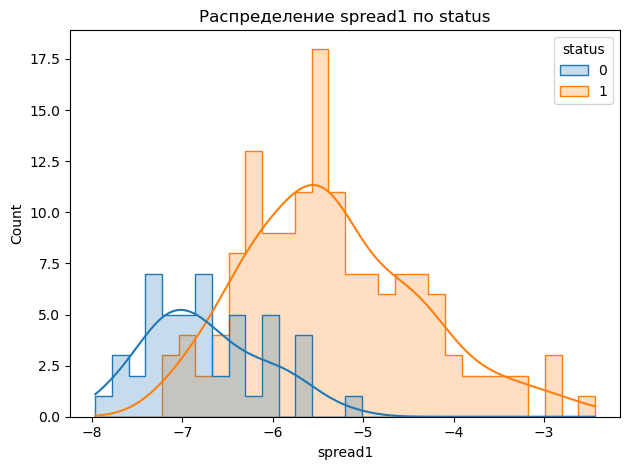

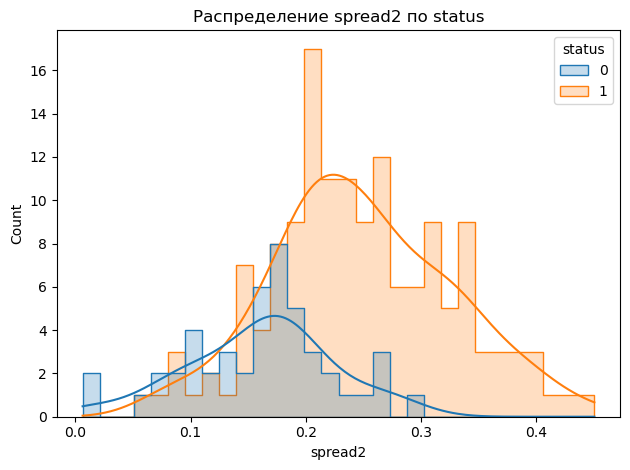

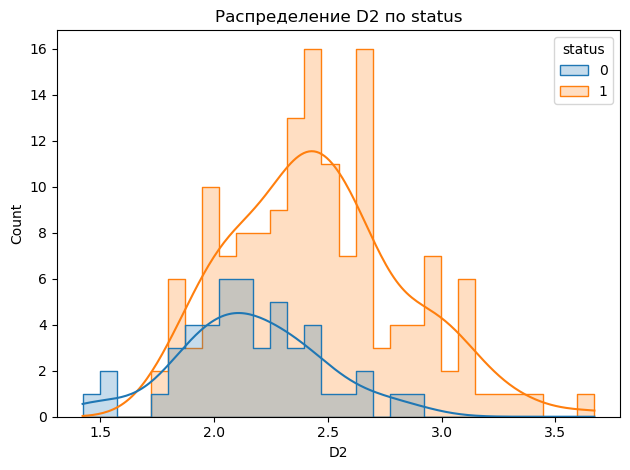

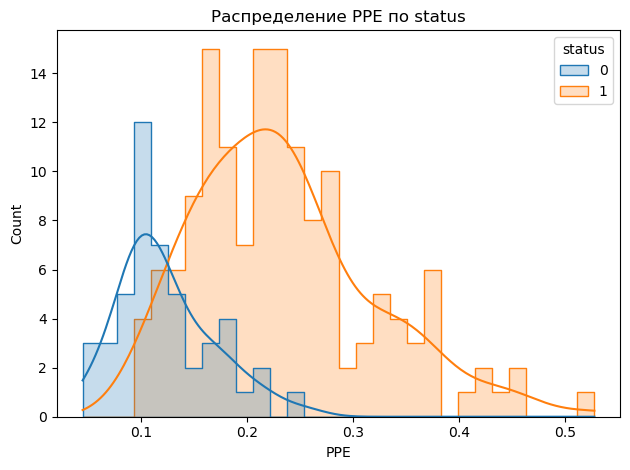

In [ ]:
# 6) Остальные признаки
for col in other_cols:
    sns.histplot(data=df, x=col, hue="status", bins=30, kde=True, element="step", common_norm=False)
    plt.title(f"Распределение {col} по status")
    plt.tight_layout()
    plt.show()


#### 7.2 Boxplot и scatter для нескольких признаков

Чтобы графики были читаемыми, выберем несколько признаков, которые сильнее всего связаны со `status` (по модулю корреляции).

In [ ]:
# Выбираем топ-6 признаков по |corr(feature, status)|
tmp = []
y = df['status']

for col in feature_cols:
    tmp.append((col, df[col].corr(y)))

top = (pd.DataFrame(tmp, columns=["feature", "corr"])
       .assign(abs_corr=lambda x: x["corr"].abs())
       .sort_values("abs_corr", ascending=False)
       .head(6))

top

,feature,corr,abs_corr
18,spread1,0.564838,0.564838
21,PPE,0.531039,0.531039
19,spread2,0.454842,0.454842
0,MDVP:Fo(Hz),-0.383535,0.383535
2,MDVP:Flo(Hz),-0.380200,0.380200
8,MDVP:Shimmer,0.367430,0.367430


In [ ]:
top_features = top["feature"].tolist()
top_features

['spread1', 'PPE', 'spread2', 'MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Shimmer']

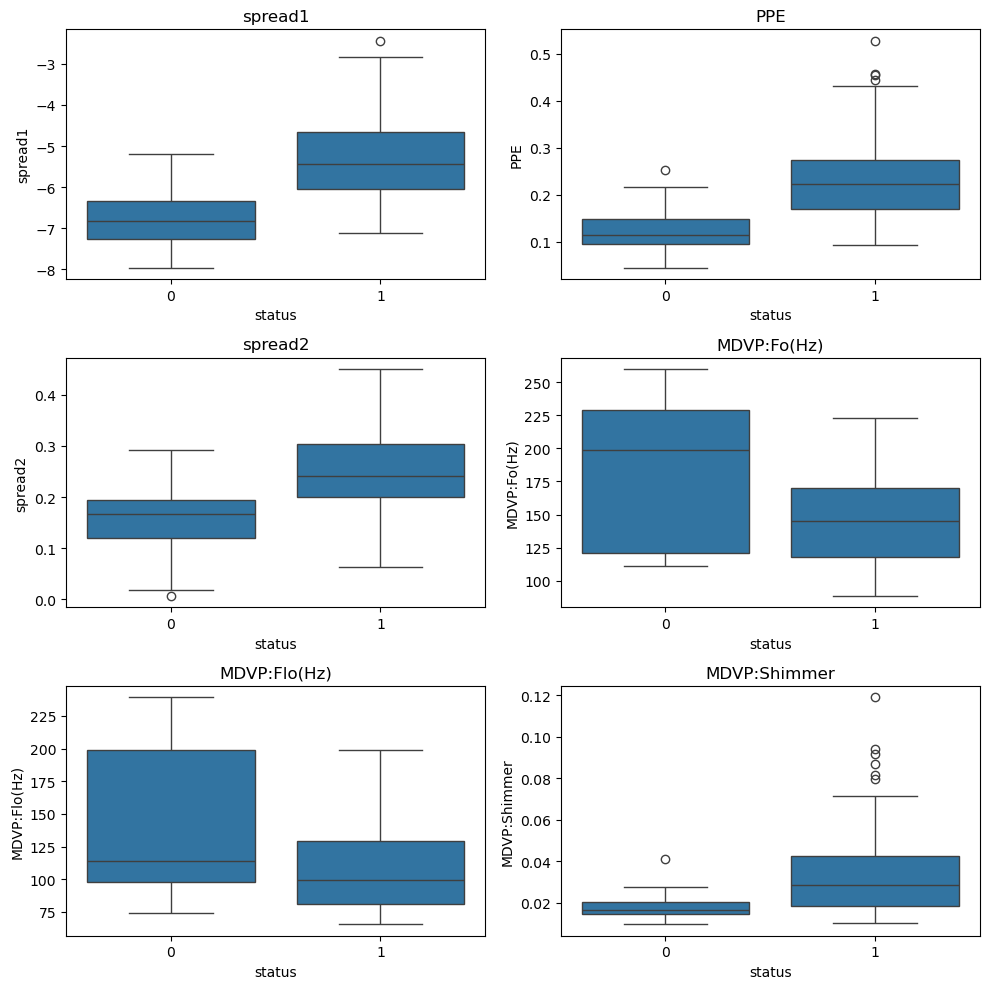

In [ ]:
# Boxplot: сравнение распределений по status
plt.figure(figsize=(10, 10))

for i, col in enumerate(top_features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=df, x="status", y=col)
    plt.title(col)
    plt.xlabel("status")

plt.tight_layout()
plt.show()


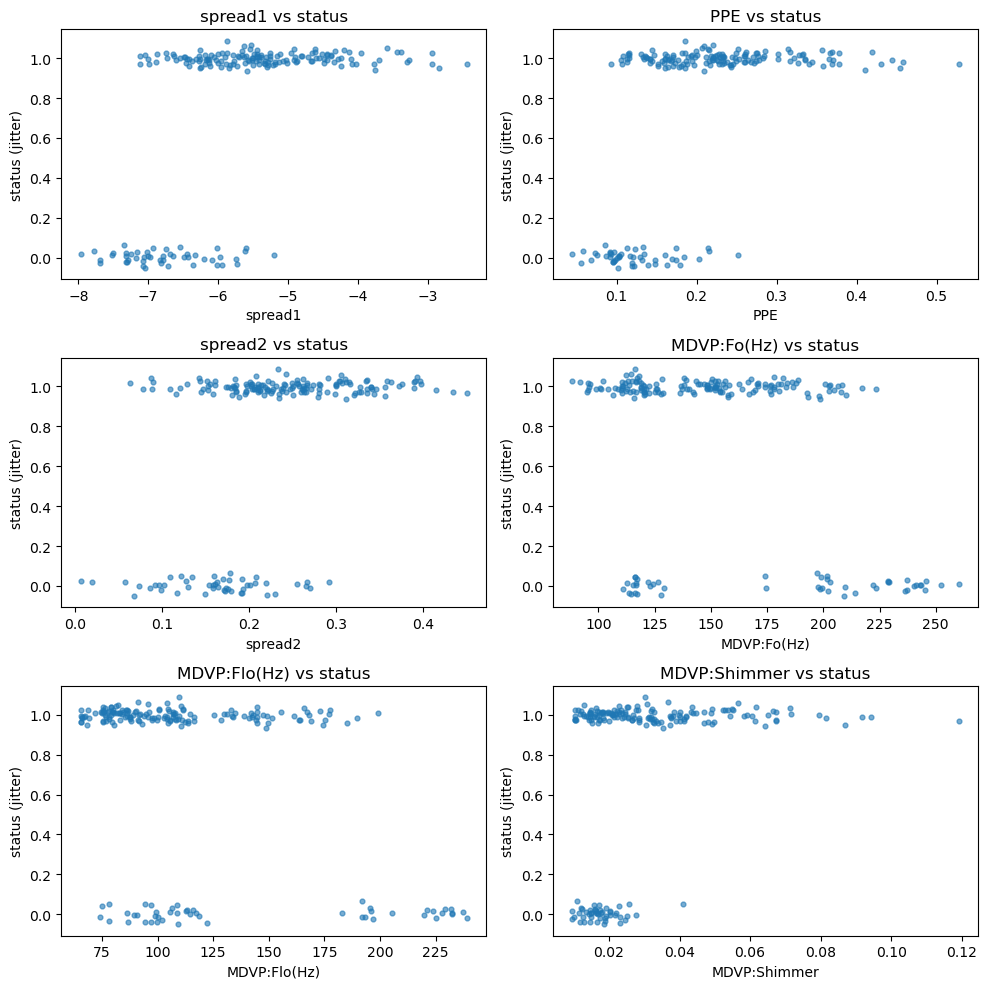

In [ ]:
# Scatter: признак vs status (с небольшим "джиттером" по оси Y)
rng = np.random.default_rng(42)
y_jitter = df["status"].astype(float) + rng.normal(0, 0.03, size=len(df))

plt.figure(figsize=(10, 10))

for i, col in enumerate(top_features, 1):
    plt.subplot(3, 2, i)
    plt.scatter(df[col], y_jitter, s=12, alpha=0.6)
    plt.title(f"{col} vs status")
    plt.ylabel("status (jitter)")
    plt.xlabel(col)

plt.tight_layout()
plt.show()


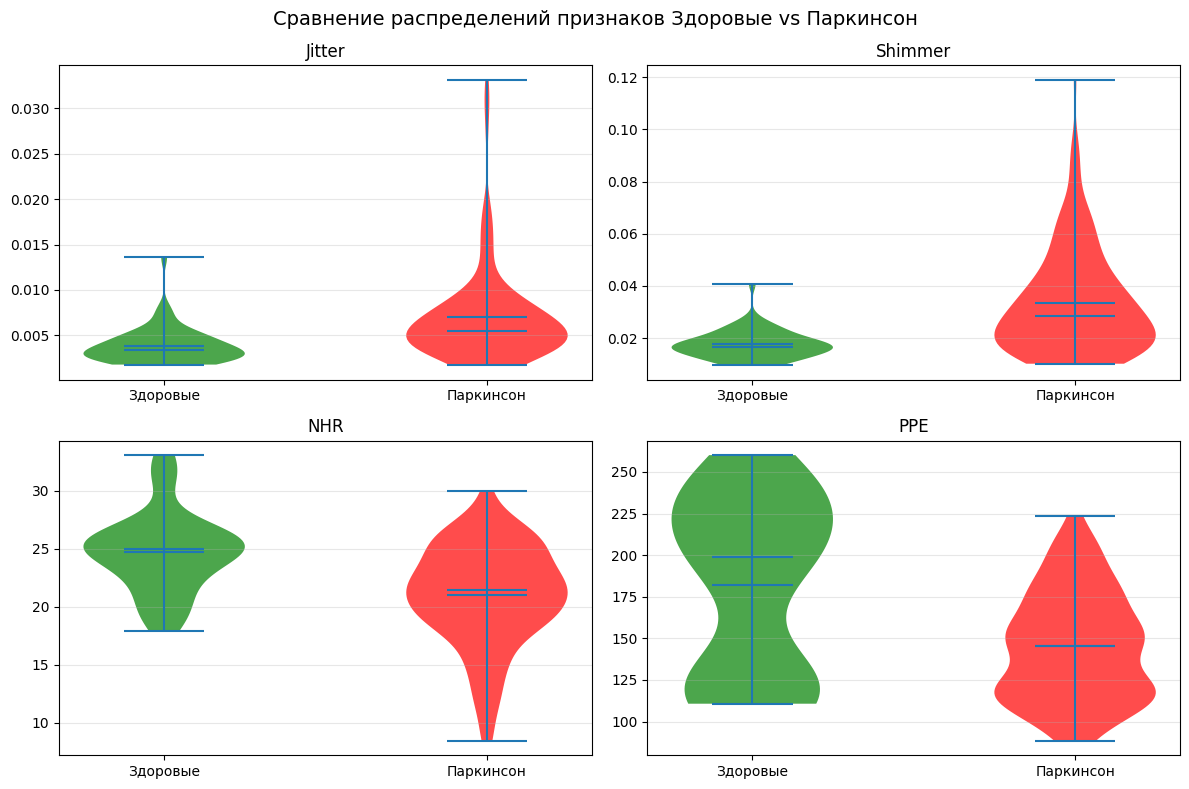

In [49]:
# Распределение признаков у здоровых и больных Паркинсон
features = ['MDVP:Jitter(%)', 'MDVP:Shimmer', 'HNR', 'MDVP:Fo(Hz)']
titles = ['Jitter', 'Shimmer', 'NHR', 'PPE']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, (feat, title) in enumerate(zip(features, titles)):
    healthy_data = df[df['status']==0][feat].dropna()
    sick_data = df[df['status']==1][feat].dropna()

    # Violin plot
    parts = axes[idx].violinplot([healthy_data, sick_data],
                                 positions=[1, 2],
                                 showmeans=True,
                                 showmedians=True)

    # Цвета
    parts['bodies'][0].set_facecolor('green')
    parts['bodies'][0].set_alpha(0.7)
    parts['bodies'][1].set_facecolor('red')
    parts['bodies'][1].set_alpha(0.7)

    axes[idx].set_xticks([1, 2])
    axes[idx].set_xticklabels(['Здоровые', 'Паркинсон'])
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Сравнение распределений признаков Здоровые vs Паркинсон', fontsize=14)
plt.tight_layout()
plt.show()

**Jitter**

У пациентов с болезнью Паркинсона наблюдается смещение распределения jitter в сторону более высоких значений. Это отражает повышенную нестабильность частоты голосовых колебаний и снижение контроля над голосовыми складками.

С клинической точки зрения увеличение jitter связано с нарушением моторного контроля гортани и характерно для гипокинетической дизартрии при болезни Паркинсона.

**Shimmer**

Аналогично jitter, показатель shimmer у пациентов с болезнью Паркинсона выше. Это говорит о нестабильности амплитуды голосового сигнала и снижении контроля силы голоса.

Это может отражать:

- гипофонии

- дрожанию голоса

- снижению устойчивости фонации

**HNR (harmonics-to-noise ratio)**

У пациентов с болезнью Паркинсона значения HNR в среднем ниже. Это означает более высокий уровень шумового компонента в голосе и снижение гармоничности.

Это может отражать:

- неполное смыкание голосовых складок

- снижение тонуса

- увеличение дыхательного шума

**MDVP:Fo (основная частота)**

Основная частота голоса у пациентов с болезнью Паркинсона демонстрирует более узкий диапазон значений и тенденцию к снижению вариабельности.

Это может отражать:

- монотонность речи

- снижение просодики

- ограничение моторного диапазона голосового аппарата

Посмотрим, можно ли визуально разделить классы при разложении по двум наиболее "разно" распределенным признакам в разрезе целевой переменной.

В качестве меры различия возьмем KL-дивергенцию.

In [50]:
def kl_divergence(dist1, dist2, bins=50):
    hist1, bins_edges = np.histogram(dist1, bins=bins, density=True)
    hist2, _ = np.histogram(dist2, bins=bins_edges, density=True)

    hist1 = hist1 + 1e-10
    hist2 = hist2 + 1e-10

    hist1 = hist1 / hist1.sum()
    hist2 = hist2 / hist2.sum()

    kl_div = entropy(hist1, hist2)

    return kl_div

In [69]:
DKL_num_features = {}

for f in feature_cols:
    dkl = kl_divergence(df[df['status'] == 0][f],
                        df[df['status'] == 1][f])
    DKL_num_features[f] = dkl

DKL_num_features = {k: v for k, v in sorted(DKL_num_features.items(),
                                            key=lambda item: item[1],
                                            reverse=True)}

In [70]:
def plot_pairs_per_target(df, columns, target, n_cols=2, figsize=(15, 10)):

    pairs = list(combinations(columns, 2))
    n_pairs = len(pairs)

    n_rows = (len(pairs) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    classes = df[target].unique()
    colors = plt.cm.viridis(np.linspace(0, 1, len(classes)))
    class_color_dict = dict(zip(classes, colors))

    for idx, (feat1, feat2) in enumerate(pairs):
        ax = axes[idx]

        for cls in classes:
            subset = df[df[target] == cls]
            ax.scatter(subset[feat1], subset[feat2],
                      c=[class_color_dict[cls]], label=f'Класс {cls}',
                      alpha=0.9)

        ax.set_xlabel(feat1)
        ax.set_ylabel(feat2)
        ax.set_title(f'{feat1} vs {feat2}')
        ax.grid(True, alpha=0.3)
        ax.legend()

    for idx in range(len(pairs), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

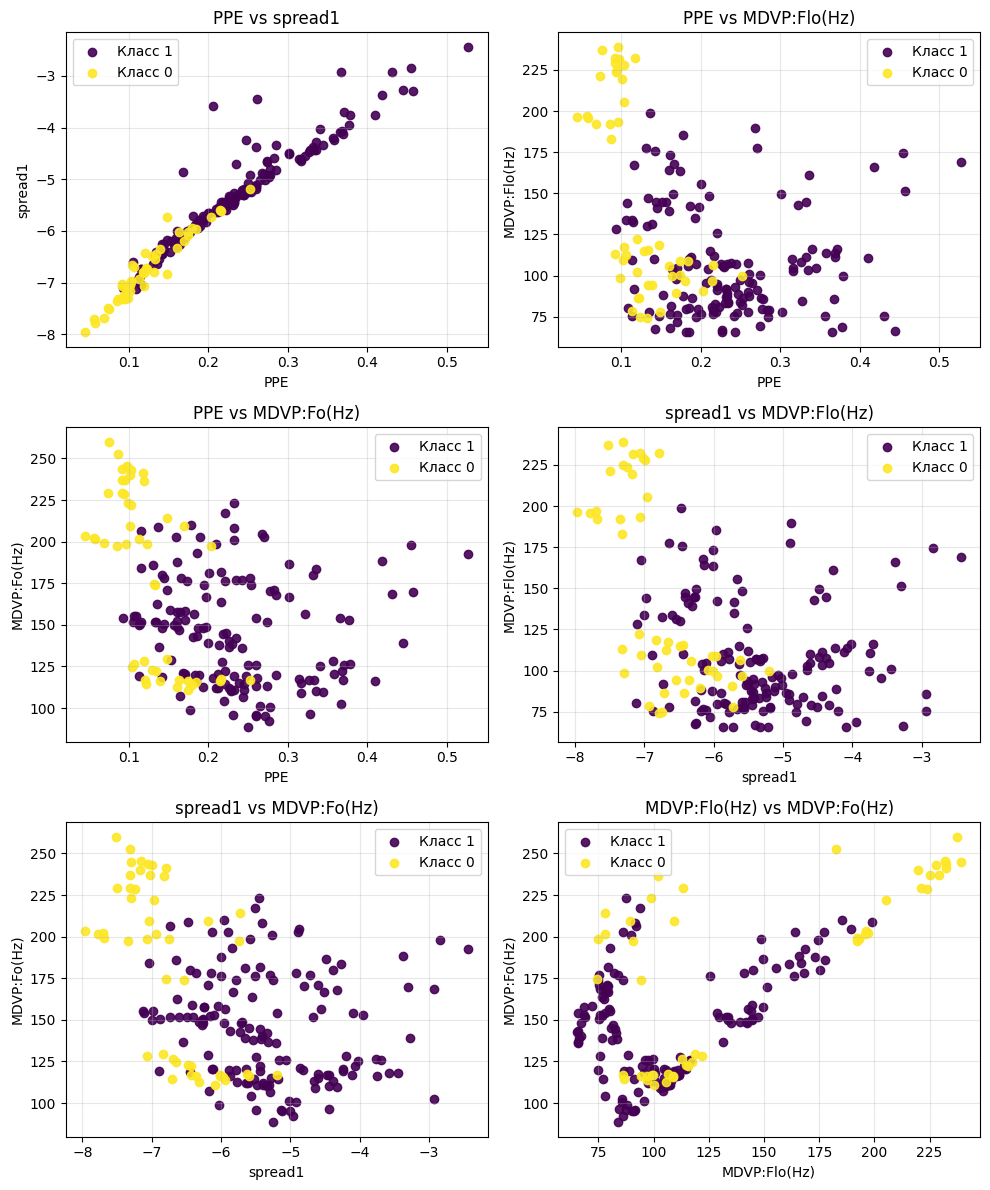

In [73]:
plot_pairs_per_target(df, list(DKL_num_features.keys())[:4], 'status', 2, (10, 12))

Из поточечных графиков распределения можно видеть, что данные, относящиеся к разным классам, в разрезе определенных признаков (с наибольшей корреляцией с таргетом) - spread1, PPE, spread2, MDVP:Fo(Hz), MDVP:Flo(Hz), визуально могут быть разделены.

**Клиническая интерпретация**

Полученные визуальные различия соответствуют проявлениям гипокинетической дизартрии при болезни Паркинсона:

- монотонность речи,

- гипофония,

- нестабильность фонации,

- увеличение шумовых компонентов.

Это подтверждает, что акустический анализ голоса может использоваться как неинвазивный инструмент скрининга болезни Паркинсона.

# Выводы

1. В данных представлено 195 записей о характеристиках голоса людей с болезнью Паркинсона (147 записей, 24 пациента) и без болезни (48 записей, 8 пациентов), соотношение 3 к 1. В данных нет пропусков, нет ошибок, все типы заданы правильно.
2. Во многих числовых признаках присутствуют выбросы (до 10–15 записей на признак) особенно в данных, относящихся к 1 классу.
3. Из гистограм распределения видно, что показатели основной частоты (MDVP) и вариации амплитуды (Shimmer) имеют скошеное распределение. Признаки семейства jitter/shimmer обладают мультиколлинеарностью (логично по физиологии), поэтому при моделировании возможно сокращение/регуляризация. Наибольшая корреляция со status наблюдается у spread1, spread2, PPE, MDVP, Shimmer.
4.  Гистограммы и boxplot подтверждают разделимость классов. Пары поточечных графиков наиболее коррелированных признаков демонстрирует области преимущественного нахождения здоровых и больных.
5. Данных относительно немного - всего 195 записей. Для улучшения предсказательной способности моделей и профилактики недообучения допускаем обогащение датесета (конкретные методы рассмотрим при непосредственном обучении моделей).